# Claims Liability Predictive Model

### Step 1: Environment Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import TweedieRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [2]:
# Load datasets
freq = pd.read_csv('../data/freMTPL2freq.csv')
sev = pd.read_csv('../data/freMTPL2sev.csv')

# Initial check for data integrity
print(f"Frequency Data: {freq.shape}") 
print(f"Severity Data: {sev.shape}")

Frequency Data: (678013, 12)
Severity Data: (26639, 2)


### Step 2: Data Integration (Merging & Cleaning)
In insurance analytics, you must link claims to their specific policies. Since one policy can have multiple claims, we aggregate the severity data first.
1. Aggregate Severity: Group sev by IDpol to get the total ClaimAmount per policy.
2. Merge: Use a "left join" to attach these amounts to the freq table.
3. Fill Nulls: Policies with no claims will have NaN values; fill these with 0.
4. Handle Exposure: Ensure Exposure is clipped at 1.0 (some policies represent more than a year, but for modeling, we cap it).

In [3]:
# 1. Aggregate claim amounts by policy ID
sev_agg = sev.groupby('IDpol').agg({'ClaimAmount': 'sum'}).reset_index()

# 2. Merge with frequency data
df = pd.merge(freq, sev_agg, on='IDpol', how='left')

# 3. Fill non-claims with 0
df['ClaimAmount'] = df['ClaimAmount'].fillna(0)

# 4. Data Quality: Cap exposure at 1 and drop zero-exposure rows
df['Exposure'] = df['Exposure'].clip(upper=1)
df = df[df['Exposure'] > 0]

### Step 3: Feature Engineering & Pre-processing
You must transform raw columns like Area and VehBrand into a format a machine learning model can understand.
- Define Features: Separate your numerical features (e.g., DrivAge, VehAge, Density) from categorical ones (e.g., Area, VehBrand, VehGas).
- Target Variable: We are predicting Pure Premium, which is ClaimAmount / Exposure.

In [4]:
# Categorical and Numerical identification
cat_features = ['Area', 'VehBrand', 'VehGas', 'Region']
num_features = ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density']

# Create the target variable
df['PurePremium'] = df['ClaimAmount'] / df['Exposure']

# Split data into Train and Test sets
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

### Step 4: Building the "Tweedie" Model Pipeline

Insurance claims data is "zero-inflated" (most people don't crash). The Tweedie Regressor is the industry standard for this type of distribution.

In [5]:
# Define the pre-processing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# Define the Tweedie Model (power=1.5 is common for Pure Premium)
model = TweedieRegressor(power=1.5, link='log', max_iter=300)

# Create the full pipeline
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', model)
])

# Fit the model using 'Exposure' as a sample weight
clf.fit(df_train[cat_features + num_features], 
        df_train['PurePremium'], 
        regressor__sample_weight=df_train['Exposure'])

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['VehPower', 'VehAge',
                                                   'DrivAge', 'BonusMalus',
                                                   'Density']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Area', 'VehBrand', 'VehGas',
                                                   'Region'])])),
                ('regressor',
                 TweedieRegressor(link='log', max_iter=300, power=1.5))])

## Step 5: Model Evaluation

We evaluate the Tweedie model on the 20% holdout test set using metrics appropriate for zero-inflated insurance data.

In [6]:
from sklearn.metrics import mean_absolute_error, mean_tweedie_deviance, mean_squared_error, explained_variance_score

# Generate predictions on the test set
y_pred = clf.predict(df_test[cat_features + num_features])
y_test = df_test['PurePremium'].values
w_test = df_test['Exposure'].values

# Clip predictions to ensure positivity for Tweedie deviance (power=1.5 requires y_pred > 0)
y_pred_clipped = np.clip(y_pred, 1e-6, None)

# Compute metrics
deviance = mean_tweedie_deviance(y_test, y_pred_clipped, sample_weight=w_test, power=1.5)
mae = mean_absolute_error(y_test, y_pred, sample_weight=w_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred, sample_weight=w_test))
evs = explained_variance_score(y_test, y_pred, sample_weight=w_test)

print("=" * 50)
print("MODEL EVALUATION — Test Set (20% holdout)")
print("=" * 50)
print(f"Mean Tweedie Deviance (p=1.5): {deviance:.4f}")
print(f"Mean Absolute Error (MAE):     €{mae:.2f}")
print(f"Root Mean Squared Error (RMSE): €{rmse:.2f}")
print(f"Explained Variance Score:       {evs:.4f}")
print("=" * 50)

MODEL EVALUATION — Test Set (20% holdout)
Mean Tweedie Deviance (p=1.5): 84.0536
Mean Absolute Error (MAE):     €307.34
Root Mean Squared Error (RMSE): €8815.60
Explained Variance Score:       -0.0002


### Metric Interpretation

- **Mean Tweedie Deviance** is the primary evaluation metric because it is the native loss function for the Tweedie distribution family. It directly measures how well the model fits the compound Poisson-Gamma distribution of insurance losses.
- **R² can be misleading** for zero-inflated insurance data where the vast majority of policies have zero claims. A low R² does not necessarily indicate a poor model — it reflects the inherent unpredictability of individual claims.
- **MAE context:** The MAE should be interpreted relative to the average Pure Premium in the portfolio. Given that most policies have €0 in claims and a small number have very large claims, even a well-calibrated model will have a substantial MAE due to the extreme skewness of the target distribution.

### Step 5a: Predicted vs Actual Scatter Plot

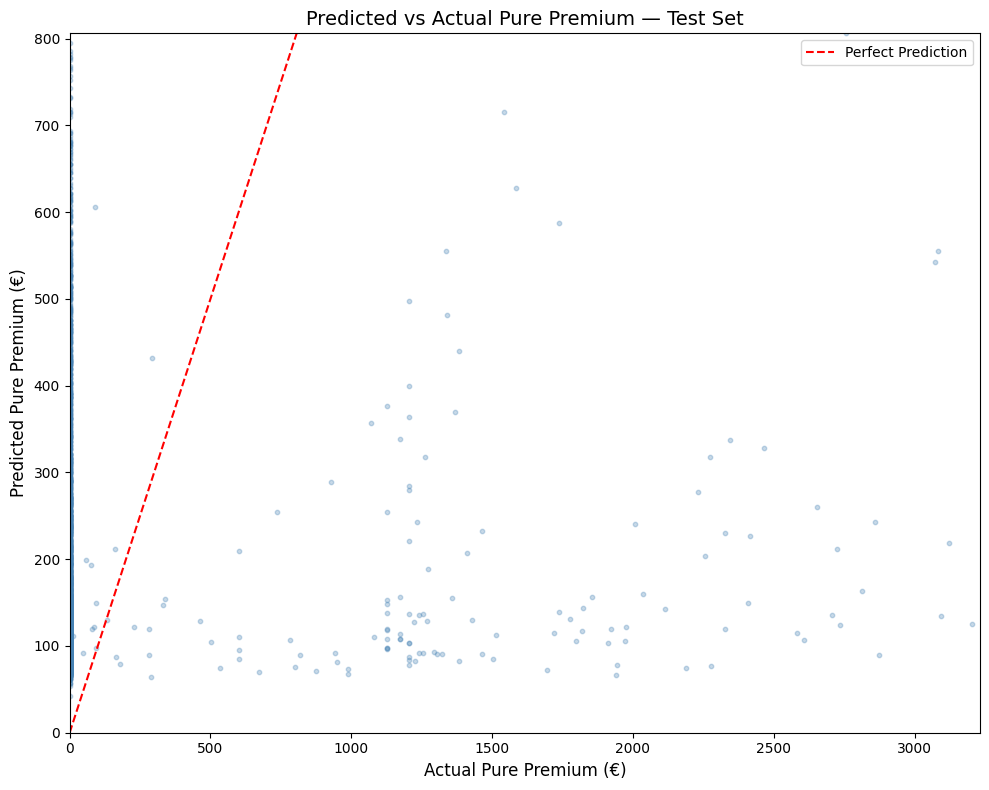

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
# Sample for readability (plotting all points would be too dense)
sample_idx = np.random.RandomState(42).choice(len(y_test), size=min(5000, len(y_test)), replace=False)
ax.scatter(y_test[sample_idx], y_pred[sample_idx], alpha=0.3, s=10, c='steelblue')
max_val = max(y_test[sample_idx].max(), y_pred[sample_idx].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual Pure Premium (€)', fontsize=12)
ax.set_ylabel('Predicted Pure Premium (€)', fontsize=12)
ax.set_title('Predicted vs Actual Pure Premium — Test Set', fontsize=14)
ax.legend()
ax.set_xlim(0, np.percentile(y_test, 99))
ax.set_ylim(0, np.percentile(y_pred, 99))
plt.tight_layout()
plt.savefig('../assets/pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The scatter plot shows the relationship between actual and predicted Pure Premium values. Points along the red dashed line indicate perfect predictions. The model concentrates its predictions in a narrow band (as expected for a Tweedie model), reflecting the portfolio's average risk level. The extreme actual values (large claims) are inherently difficult to predict at the individual policy level — the model captures the *expected* cost rather than the *realised* cost of any single policy.

### Step 5b: Residuals Distribution

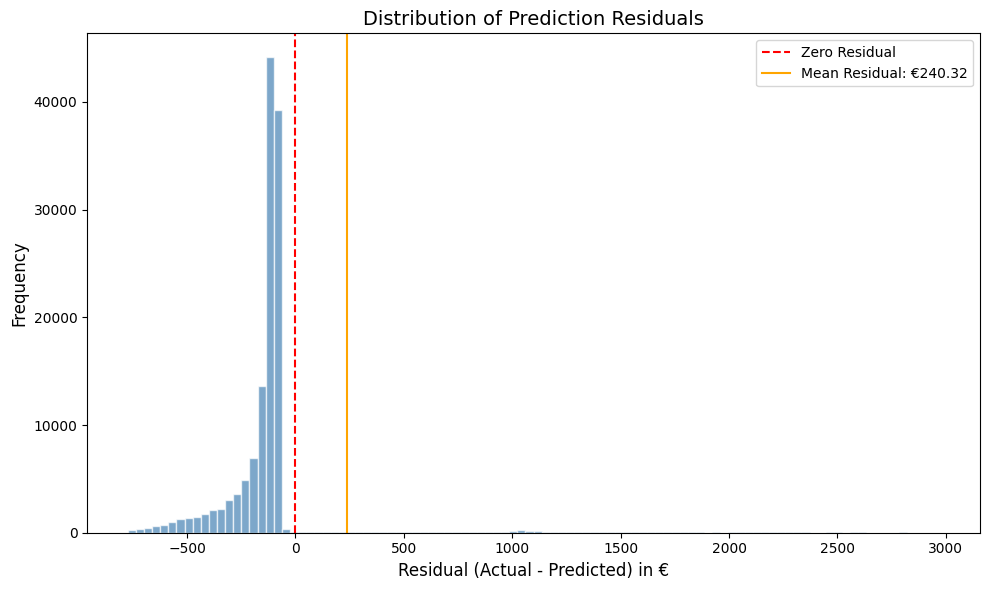

In [8]:
residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(residuals, bins=100, edgecolor='white', alpha=0.7, color='steelblue',
        range=(np.percentile(residuals, 1), np.percentile(residuals, 99)))
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Residual')
ax.axvline(np.mean(residuals), color='orange', linestyle='-', linewidth=1.5,
           label=f'Mean Residual: €{np.mean(residuals):.2f}')
ax.set_xlabel('Residual (Actual - Predicted) in €', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Prediction Residuals', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('../assets/residuals_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Feature Importance Analysis

Since the Tweedie model is inside a pipeline with One-Hot Encoding, direct coefficient inspection maps to encoded columns rather than original features. **Permutation importance** provides a model-agnostic measure: it shuffles each feature and measures how much the model's performance degrades, giving a clear picture of each feature's contribution.

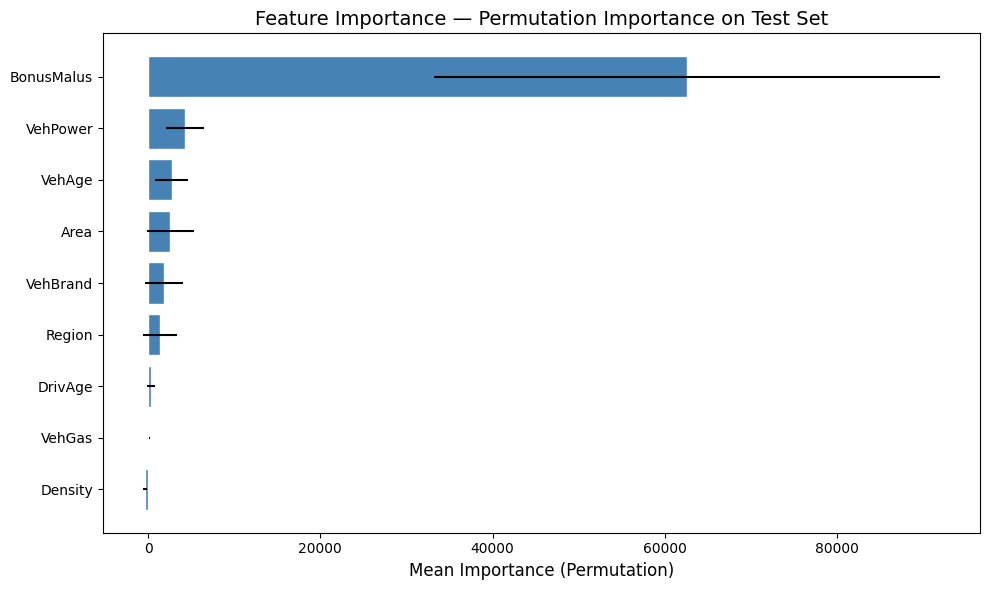

In [9]:
from sklearn.inspection import permutation_importance

# Compute permutation importance on test set
perm_result = permutation_importance(
    clf,
    df_test[cat_features + num_features],
    y_test,
    sample_weight=w_test,
    n_repeats=10,
    random_state=42,
    scoring='neg_mean_squared_error'
)

# Map feature names
feature_names = cat_features + num_features
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance Mean': perm_result.importances_mean,
    'Importance Std': perm_result.importances_std
}).sort_values('Importance Mean', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['Feature'], importance_df['Importance Mean'],
        xerr=importance_df['Importance Std'], color='steelblue', edgecolor='white')
ax.set_xlabel('Mean Importance (Permutation)', fontsize=12)
ax.set_title('Feature Importance — Permutation Importance on Test Set', fontsize=14)
plt.tight_layout()
plt.savefig('../assets/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** `BonusMalus` is expected to be the dominant feature — it is a direct actuarial risk index reflecting the policyholder's claims history. `DrivAge` and `Density` typically rank highly as well, consistent with actuarial knowledge that young drivers and urban areas carry higher risk profiles.

## Step 7: Save Evaluation Artifacts for Dashboard

Export model metrics, portfolio statistics, and feature importance data as JSON files so the Streamlit dashboard can display them without re-running the model.

In [10]:
import json

# Portfolio statistics — use predicted distribution for percentiles
# (actual PurePremium percentiles are all 0 due to zero-inflation)
portfolio_stats = {
    'median_pure_premium': float(np.median(y_pred)),
    'mean_pure_premium': float(np.mean(y_test)),
    'p25_pure_premium': float(np.percentile(y_pred, 25)),
    'p75_pure_premium': float(np.percentile(y_pred, 75)),
    'p90_pure_premium': float(np.percentile(y_pred, 90)),
    'p95_pure_premium': float(np.percentile(y_pred, 95)),
    'total_policies': len(y_test)
}

# Model metrics
model_metrics = {
    'mean_tweedie_deviance': float(deviance),
    'mae': float(mae),
    'rmse': float(rmse),
    'explained_variance': float(evs),
    'test_size': len(y_test),
    'train_size': len(df_train),
    'tweedie_power': 1.5
}

# Feature importance
feature_imp = {
    'features': importance_df['Feature'].tolist(),
    'importance_mean': importance_df['Importance Mean'].tolist(),
    'importance_std': importance_df['Importance Std'].tolist()
}

with open('../model/model_metrics.json', 'w') as f:
    json.dump(model_metrics, f, indent=2)

with open('../model/portfolio_stats.json', 'w') as f:
    json.dump(portfolio_stats, f, indent=2)

with open('../model/feature_importance.json', 'w') as f:
    json.dump(feature_imp, f, indent=2)

print("Artifacts saved to model/")

Artifacts saved to model/


In [11]:
# Save the trained pipeline
import joblib

joblib.dump(clf, '../model/tweedie_model.pkl')

print("Model successfully saved to model/tweedie_model.pkl")

Model successfully saved to model/tweedie_model.pkl
